# Chapter 18 — Shear Stress and Strain

Companion notebook to Chapter 18 — Shear Stress and Strain.

Shear is the mode of deformation most often overlooked in introductory stress analysis, and most commonly encountered in real structures. Beams shear as well as bend. Shafts twist. Adhesive layers carry load almost entirely in shear. Any complete experimental stress analysis must account for shear — and strain gages, properly oriented, are the standard tool for measuring it.

This notebook works through two canonical shear problems: the transverse shear distribution in a rectangular beam cross-section (where the parabolic *Jourawski* distribution puts maximum shear at the neutral axis, not at the surface where gages typically live) and torsion in a circular shaft (where the ±45° principal strain orientation dictates gage placement). Both are exact analytical solutions that serve as benchmarks for gage-placement decisions.

**This notebook demonstrates:**
1. Transverse shear stress distribution τ(y) in a rectangular beam — parabolic profile, maximum at the neutral axis
2. Torsional shear stress distribution in a solid circular shaft — linear radial profile, ±45° principal directions

In [1]:
# Colab setup — uncomment to install dependencies:
# !pip install numpy matplotlib

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All figures are written here; the book includes these exact files — do not rename them.
OUT_DIR = Path("../src/media/ch18")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Transverse Shear in a Rectangular Beam

The Jourawski formula τ = VQ / (Ib) gives the shear stress on any horizontal plane at height y above the neutral axis. Q is the first moment of the area above that plane, b is the section width, and I is the second moment of area. For a rectangular section, Q varies parabolically with y, which means shear stress also varies parabolically — peaking at the neutral axis (y = 0) and dropping to zero at the top and bottom surfaces.

This profile is critical for gage placement. A gage mounted on the outer surface of a beam in pure bending reads maximum bending strain; a gage at the neutral axis reads maximum shear strain and zero bending strain. When both bending and shear are present — as in most practical beam problems — the gage location determines what combination of effects it sees. The left panel shows the cross-section geometry; the right shows the parabolic shear distribution and the neutral-axis maximum.

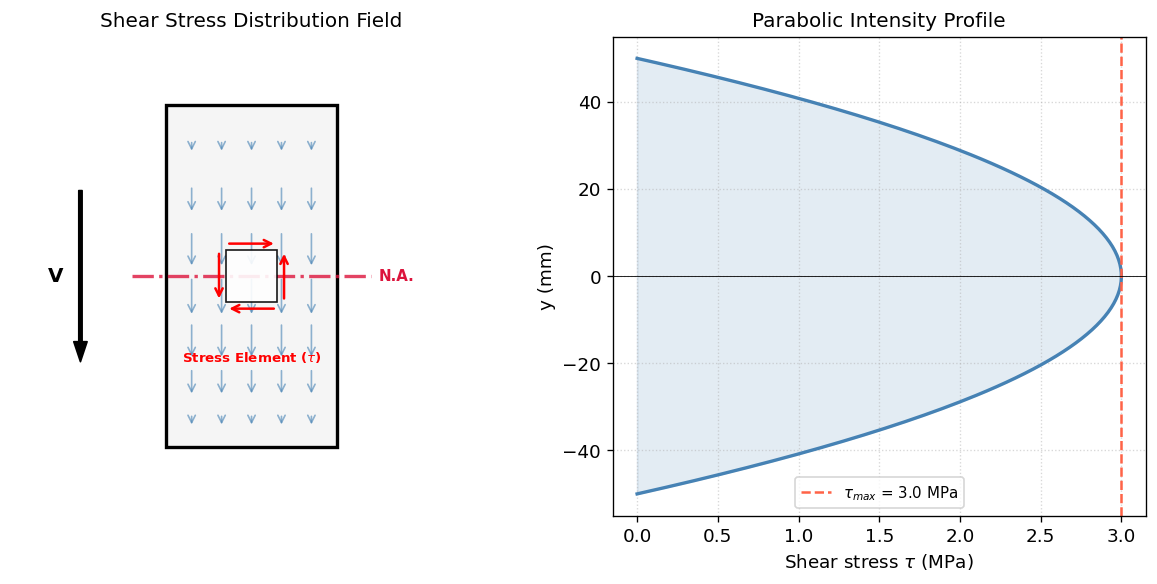

Maximum shear stress at neutral axis: τ_max = 3.000 MPa
τ_max / (V/A) = 1.50  (1.5 for a rectangular section)


In [2]:
# Transverse shear in a rectangular beam cross-section (Jourawski shear formula).
#   τ(y) = V·Q(y) / (I·b),  with  Q(y) = (b/2)·(h²/4 − y²)  for a rectangle.
# Shear is zero at the top/bottom fibers and maximum at the neutral axis (y = 0).

# --- USER INPUT: beam section and loading ---
V = 10_000    # N   transverse shear force at the section
b = 0.05      # m   section width
h = 0.10      # m   section depth

N_PROFILE = 200   # points used to draw the τ(y) profile


def transverse_shear_stress(y, V, b, h):
    """Jourawski shear stress τ(y) in a rectangular beam cross-section.

    Parameters
    ----------
    y : float or ndarray
        Height above the neutral axis (m), valid for -h/2 <= y <= h/2.
    V : float
        Transverse shear force at the section (N).
    b, h : float
        Section width and depth (m).

    Returns
    -------
    float or ndarray
        Shear stress (Pa): parabolic, maximum at y = 0, zero at y = ±h/2.
    """
    I = b * h**3 / 12.0                    # second moment of area (m^4)
    Q = 0.5 * b * (h**2 / 4.0 - y**2)      # first moment of area above y (m^3)
    return V * Q / (I * b)


y = np.linspace(-h / 2, h / 2, N_PROFILE)
tau = transverse_shear_stress(y, V, b, h)          # Pa
tau_max = 1.5 * V / (b * h)                         # theoretical peak at the neutral axis

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---- Left panel: cross-section with the shear field and a stress element ----
bm, hm = b * 1000, h * 1000     # section size in mm for plotting
rect = plt.Rectangle((-bm/2, -hm/2), bm, hm, facecolor='whitesmoke', edgecolor='black', lw=2)
axes[0].add_patch(rect)

# Neutral axis
na_ext = bm * 0.7
axes[0].plot([-na_ext, na_ext], [0, 0], color='crimson', lw=2, linestyle='-.', alpha=0.8)
axes[0].text(na_ext + 2, 0, 'N.A.', color='crimson', va='center', fontweight='bold', fontsize=9)

# Shear field: vertical arrows whose length tracks τ(y) — longest at the neutral axis.
ARROW_SCALE_MM = 12   # arrow length (mm) at τ = τ_max
for ix in np.linspace(-bm/2 * 0.7, bm/2 * 0.7, 5):
    for y_m in np.linspace(-h/2 * 0.8, h/2 * 0.8, 7):
        length = transverse_shear_stress(y_m, V, b, h) / tau_max * ARROW_SCALE_MM
        if length > 1:
            y_mm = y_m * 1000
            axes[0].annotate('', xy=(ix, y_mm - length), xytext=(ix, y_mm),
                             arrowprops=dict(arrowstyle='->', color='steelblue', lw=1, alpha=0.6))

# Stress element at the neutral axis showing complementary (equal-and-opposite) shear.
el_size = 15
el_rect = plt.Rectangle((-el_size/2, -el_size/2), el_size, el_size,
                        facecolor='white', edgecolor='black', lw=1, alpha=0.9, zorder=10)
axes[0].add_patch(el_rect)

# Complementary shear: the vertical and horizontal couples must balance, so the arrows
# converge on one diagonal — right face up, left face down, top face right, bottom face left.
axes[0].annotate('', xy=(el_size/2 + 2, el_size/2), xytext=(el_size/2 + 2, -el_size/2),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5), zorder=11)   # right: up
axes[0].annotate('', xy=(-el_size/2 - 2, -el_size/2), xytext=(-el_size/2 - 2, el_size/2),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5), zorder=11)   # left: down
axes[0].annotate('', xy=(el_size/2, el_size/2 + 2), xytext=(-el_size/2, el_size/2 + 2),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5), zorder=11)   # top: right
axes[0].annotate('', xy=(-el_size/2, -el_size/2 - 2), xytext=(el_size/2, -el_size/2 - 2),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5), zorder=11)   # bottom: left

axes[0].text(0, -el_size-10, 'Stress Element ($\\tau$)', ha='center', color='red', fontsize=8, fontweight='bold')

# Applied transverse shear force V
axes[0].annotate('', xy=(-bm/2-25, -hm/4), xytext=(-bm/2-25, hm/4),
                 arrowprops=dict(facecolor='black', width=2, headwidth=8))
axes[0].text(-bm/2-30, 0, 'V', va='center', ha='right', fontweight='bold', fontsize=12)

axes[0].set_xlim(-bm*1.4, bm*1.4); axes[0].set_ylim(-hm*0.7, hm*0.7)
axes[0].set_aspect('equal')
axes[0].axis('off')
axes[0].set_title('Shear Stress Distribution Field')

# ---- Right panel: parabolic τ(y) profile ----
axes[1].plot(tau/1e6, y*1000, 'steelblue', lw=2)
axes[1].fill_betweenx(y*1000, 0, tau/1e6, color='steelblue', alpha=0.15)
axes[1].axvline(tau_max/1e6, color='tomato', lw=1.5, linestyle='--',
                label=f'$\\tau_{{max}}$ = {tau_max/1e6:.1f} MPa')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_xlabel('Shear stress $\\tau$ (MPa)'); axes[1].set_ylabel('y (mm)')
axes[1].grid(True, linestyle=':', alpha=0.5)
axes[1].legend(loc='lower center', fontsize=9)
axes[1].set_title('Parabolic Intensity Profile')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig18_nb1_beam_shear_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Maximum shear stress at neutral axis: τ_max = {tau_max/1e6:.3f} MPa")
print(f"τ_max / (V/A) = {tau_max / (V / (b*h)):.2f}  (1.5 for a rectangular section)")

---
## 2 — Torsion in a Circular Shaft

Under torque T, a circular shaft develops shear stress that increases linearly from zero at the axis to a maximum τ_max = Tr/J at the outer surface, where J is the polar second moment of area. The shear stress acts on the cross-sectional plane and on the longitudinal plane — together they define the stress state at any point on the shaft surface.

On the outer surface, the principal stresses are equal in magnitude and opposite in sign (±τ_max), oriented at 45° to the shaft axis. This is why torsion gages are always mounted at ±45° — that orientation aligns with the principal strain directions and gives the maximum possible sensitivity. A single gage at +45° reads the tensile principal strain ε₁ = +τ_max/(2G) = γ/2; a ±45° half-bridge differences its two grids to read the full engineering shear strain γ = τ_max/G, doubling the output while cancelling bending.

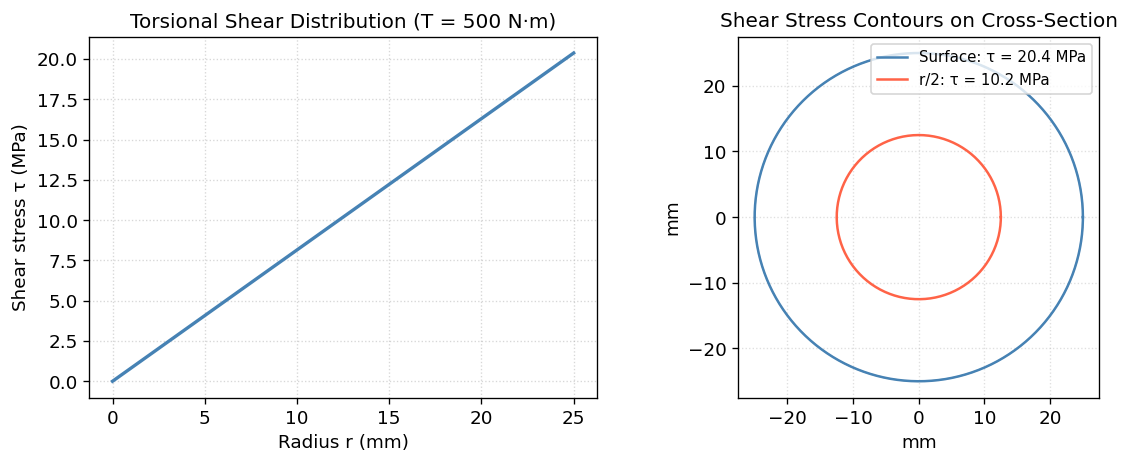

J = 613.592 × 10⁻⁹ m⁴
τ_max (outer surface) = 20.37 MPa
Angle of twist φ = 0.2918°  (5.0930 mrad)

To measure torsion with strain gages: mount at ±45° to the shaft axis.
Principal strains at 45°: ε₁ = -ε₂ = τ_max/(2G) = 127.32 με


In [3]:
# Torsion of a solid circular shaft.
#   Shear stress:   τ(r) = T·r / J          (linear: 0 at the axis, max at the surface)
#   Angle of twist: φ    = T·L / (G·J)
#   Polar moment:   J    = (π/2)·(r_o⁴ − r_i⁴)   (set r_i = 0 for a solid shaft)

# --- USER INPUT: shaft geometry, material, and loading ---
T = 500        # N·m   applied torque
R_O = 0.025    # m     outer radius
R_I = 0.0      # m     inner radius (0 for a solid shaft)
L = 0.5        # m     shaft length
G = 80e9       # Pa    shear modulus (steel ≈ 80 GPa)

N_RADIAL = 100   # points used to draw the τ(r) profile


def polar_moment(r_o, r_i=0.0):
    """Polar second moment of area J = (π/2)(r_o⁴ − r_i⁴) of a circular section (m⁴)."""
    return np.pi / 2.0 * (r_o**4 - r_i**4)


def torsional_shear_stress(r, T, J):
    """Torsional shear stress τ = T·r/J at radius r (Pa)."""
    return T * r / J


J = polar_moment(R_O, R_I)
tau_max = torsional_shear_stress(R_O, T, J)
phi_rad = T * L / (G * J)
phi_deg = np.degrees(phi_rad)

r_range = np.linspace(R_I, R_O, N_RADIAL)
tau_r = torsional_shear_stress(r_range, T, J)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ---- Left panel: linear τ(r) profile ----
axes[0].plot(r_range*1000, tau_r/1e6, 'steelblue', lw=2)
axes[0].set_xlabel('Radius r (mm)'); axes[0].set_ylabel('Shear stress τ (MPa)')
axes[0].set_title(f'Torsional Shear Distribution (T = {T} N·m)')
axes[0].grid(True, linestyle=':', alpha=0.5)

# ---- Right panel: shear-magnitude contours on the cross-section ----
theta = np.linspace(0, 2*np.pi, 300)
for r, color, label_prefix in [(R_O, 'steelblue', 'Surface'), (R_O*0.5, 'tomato', 'r/2')]:
    tau_here = torsional_shear_stress(r, T, J) / 1e6
    axes[1].plot(r*np.cos(theta)*1000, r*np.sin(theta)*1000, color=color,
                 label=f'{label_prefix}: τ = {tau_here:.1f} MPa')

circle = plt.Circle((0, 0), R_O*1000, fill=False, color='black', alpha=0.2)
axes[1].add_patch(circle)

axes[1].set_aspect('equal'); axes[1].legend(fontsize=9, loc='upper right')
axes[1].set_xlabel('mm'); axes[1].set_ylabel('mm')
axes[1].set_title('Shear Stress Contours on Cross-Section')
axes[1].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig18_nb2_torsion_shear_stress.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"J = {J*1e9:.3f} × 10⁻⁹ m⁴")
print(f"τ_max (outer surface) = {tau_max/1e6:.2f} MPa")
print(f"Angle of twist φ = {phi_deg:.4f}°  ({phi_rad*1000:.4f} mrad)")
print()
print("To measure torsion with strain gages: mount at ±45° to the shaft axis.")
print(f"Principal strains at 45°: ε₁ = -ε₂ = τ_max/(2G) = {tau_max/(2*G)*1e6:.2f} με")

---
## Where to take this next

These two closed-form solutions are the benchmarks against which any real gage installation is judged. A few concrete extensions:

1. **Add a hollow shaft and compare.** Set `R_I > 0` in the torsion cell and plot `τ_max` and the angle of twist versus wall thickness for a fixed outer radius. You will see how a thin-walled tube reaches nearly the same surface stress as a solid shaft at a fraction of the weight — the reasoning behind hollow torque-tube transducers (Chapter 44).
2. **Build the ±45° torsion bridge.** From the surface shear `τ_max`, compute the two principal strains `ε₁ = +τ_max/(2G)` and `ε₂ = −τ_max/(2G)`, then model a four-gage full bridge and confirm that its output is proportional to torque `T` while bending and axial strains cancel to first order (Chapter 26).
3. **Superpose bending and shear in the beam.** Add a bending-stress profile `σ = M·y/I` to the transverse-shear cell and sweep the gage height `y`. Show that a gage on the outer fiber sees pure bending while one at the neutral axis sees pure shear — the exact trade-off that governs shear-beam load-cell design.